In [2]:
## Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [6]:
X = 6 * np.random.rand(100, 1) - 3 # generate 100 random numbers between -3 and 3
y = 0.5 * X**2 + 1.5 * X + 2 + np.random.randn(100, 1) # generate the target variable with some noise



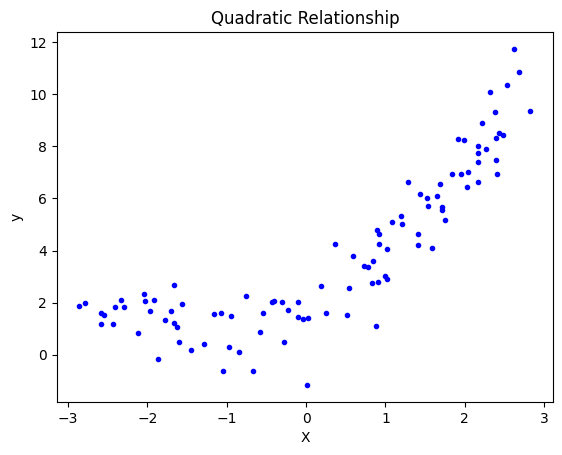

In [11]:
## Now plotting that quadratic relationship
plt.plot(X, y, 'b.') # plot the data points
plt.xlabel('X')
plt.ylabel('y')
plt.title('Quadratic Relationship')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # split the data into training and testing sets


In [14]:
## Lets first implement linear regression to see how it performs on this data
from sklearn.linear_model import LinearRegression
model = LinearRegression() # create an instance of the LinearRegression class
model.fit(X_train, y_train) # fit the model to the training data
y_pred = model.predict(X_test) # make predictions on the test set

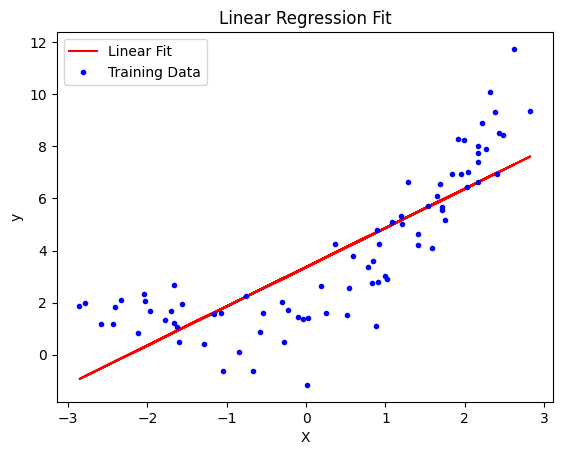

In [16]:
plt.plot(X_train, model.predict(X_train), 'r-', label='Linear Fit') # plot the linear fit
plt.plot(X_train, y_train, 'b.', label='Training Data') # plot the training data
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, adjusted_rand_score, mean_absolute_error, root_mean_squared_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
adj_r2 = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
root_mse = root_mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Adjusted R-squared: {adj_r2}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {root_mse}')


Mean Squared Error: 2.3931047843847333
R-squared: 0.7727764978541234
Adjusted R-squared: 1.546966316499727
Mean Absolute Error: 1.2779780214379226
Root Mean Squared Error: 1.546966316499727


In [48]:
#Lets now apply polynomial Transformation to the data and see how it performs
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=4, include_bias=True) # create an instance of the PolynomialFeatures class with degree 2 and include_bias=True to add the bias term to the features that means it will add a column of ones to the features to account for the intercept term in the linear regression model.

X_train_poly = poly.fit_transform(X_train) # transform the training data to include polynomial features
X_test_poly = poly.transform(X_test) # transform the test data to include polynomial features




In [49]:
X_train_poly

array([[ 1.00000000e+00,  1.94950837e+00,  3.80058290e+00,
         7.40926818e+00,  1.44444303e+01],
       [ 1.00000000e+00,  1.41593523e+00,  2.00487258e+00,
         2.83876972e+00,  4.01951407e+00],
       [ 1.00000000e+00,  1.71009213e+00,  2.92441509e+00,
         5.00101922e+00,  8.55220359e+00],
       [ 1.00000000e+00,  3.66621816e-01,  1.34411556e-01,
         4.92782087e-02,  1.80664664e-02],
       [ 1.00000000e+00,  2.48252875e+00,  6.16294901e+00,
         1.52996981e+01,  3.79819405e+01],
       [ 1.00000000e+00,  1.08645780e+00,  1.18039056e+00,
         1.28244454e+00,  1.39332188e+00],
       [ 1.00000000e+00, -1.66579235e+00,  2.77486415e+00,
        -4.62234748e+00,  7.69987106e+00],
       [ 1.00000000e+00, -2.32984979e+00,  5.42820005e+00,
        -1.26468907e+01,  2.94653558e+01],
       [ 1.00000000e+00,  1.64572381e+00,  2.70840686e+00,
         4.45728966e+00,  7.33546772e+00],
       [ 1.00000000e+00, -5.46646968e-01,  2.98822907e-01,
        -1.63350636e-01

In [50]:
model_poly = LinearRegression() # create an instance of the LinearRegression class
model_poly.fit(X_train_poly, y_train) # fit the model to the training data
y_poly_pred = model_poly.predict(X_test_poly) # make predictions on the test set

In [51]:
## Performance Metrics for Polynomial Regression
mse_poly = mean_squared_error(y_test, y_poly_pred)
r2_poly = r2_score(y_test, y_poly_pred)
adj_r2_poly = root_mean_squared_error(y_test, y_poly_pred)
mae_poly = mean_absolute_error(y_test, y_poly_pred)
root_mse_poly = root_mean_squared_error(y_test, y_poly_pred)
print(f'Mean Squared Error: {mse_poly}')
print(f'R-squared: {r2_poly}')
print(f'Adjusted R-squared: {adj_r2_poly}')
print(f'Mean Absolute Error: {mae_poly}')
print(f'Root Mean Squared Error: {root_mse_poly}')


Mean Squared Error: 0.724279170684561
R-squared: 0.9312302366498469
Adjusted R-squared: 0.8510459274825073
Mean Absolute Error: 0.7484391629277604
Root Mean Squared Error: 0.8510459274825073


/var/folders/dp/s5clf43x0x35xx5d020f4y3c0000gn/T/ipykernel_15018/1768763034.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


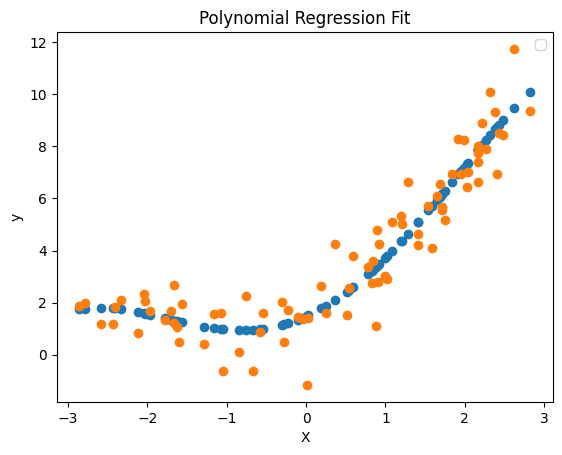

In [52]:
# Les plot now what we did with polynomial regression
plt.scatter(X_train, model_poly.predict(X_train_poly)) # plot the polynomial fit
plt.scatter(X_train, y_train) # plot the training data
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression Fit')
plt.legend()
plt.show()

In [60]:
# Now creating a pipeline to streamline the process of polynomial regression
from sklearn.pipeline import Pipeline

In [59]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1) # create a new set of X values for plotting the polynomial fit having 200 points between -3 and 3
    poly_features = PolynomialFeatures(degree=degree, include_bias=True) # create an instance of the PolynomialFeatures class with degree 2 and include_bias=True to add the bias term to the features that means it will add a column of ones to the features to account for the intercept term in the linear regression model.
    linear_regression = LinearRegression() # create an instance of the LinearRegression class
    poly_regression = Pipeline([
        ('poly_features', poly_features),
        ('linear_regression', linear_regression)
    ]) # create a pipeline that first transforms the features to include polynomial features and then fits a linear regression model to the transformed features
    poly_regression.fit(X_train, y_train) # fit the pipeline to the training data
    y_pred_new = poly_regression.predict(X_new) # make predictions on the new X values
    ## plotting the prediction line
    plt.plot(X_new, y_pred_new, 'r-', label=f'Polynomial Fit (degree={degree})') # plot the polynomial fit
    plt.scatter(X_train, y_train, label='Training Data') # plot the training data
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Polynomial Regression Fit (degree={degree})')
    plt.legend()
    plt.show()

### Training 

 X_train
  ->
PolynomialFeatures (fit + transform)
   ->
X_train_poly
   ->
LinearRegression (fit)


### Prediction
X_new
  ->
PolynomialFeatures (transform only)
   ->
X_new_poly
   ->
LinearRegression (predict)

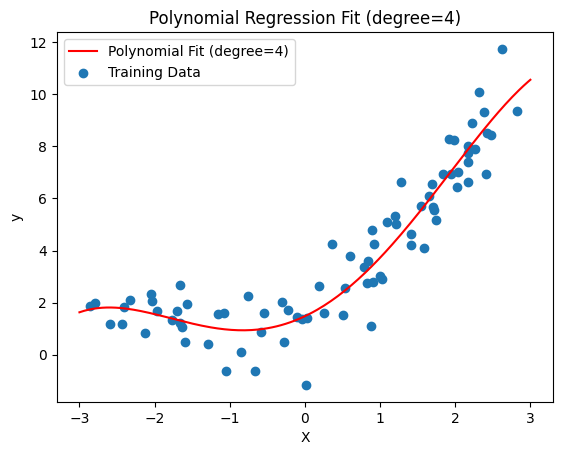

In [61]:
poly_regression(degree=4)